# 08 — t-SNE Embedding Visualisation (10 classes)

Extract 256-dimensional embeddings from the penultimate layer of the trained
`AudioCNN`, reduce them to 2D with t-SNE, and visualise the 10 acoustic categories
in multiple complementary figures.

### Input files
| File | Produced by |
|---|---|
| `data/features_manifest.csv` | Notebook 03 |
| `data/norm_stats_logmel.npz` | Notebook 04 |
| `checkpoints/logmel_best.ckpt` | Notebook 05 |

### Output files
| File | Content |
|---|---|
| `data/embeddings_logmel.npz` | Raw 256-d embeddings + labels |
| `data/tsne_2d_logmel.npz` | 2-D t-SNE coordinates |
| `fig_tsne_*.png` | Figures 1 – 5 |


## 0. Imports & configuration

In [2]:
import time as _time
_NOTEBOOK_START = _time.perf_counter()

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
from matplotlib.colors import LinearSegmentedColormap
from scipy.spatial import ConvexHull

import torch
import torch.nn as nn
import pytorch_lightning as pl
from torch.utils.data import Dataset, DataLoader

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.facecolor': '#fafafa',
    'figure.facecolor': 'white',
    'font.size': 10,
})

SEED = 42
pl.seed_everything(SEED, workers=True)
print(f"PyTorch  : {torch.__version__}")
print(f"Lightning: {pl.__version__}")

Seed set to 42


PyTorch  : 2.10.0+cpu
Lightning: 2.6.1


In [4]:
# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT          = Path("data")
MANIFEST_CSV  = ROOT / "features_manifest.csv"
CKPT_PATH     = Path("checkpoints/logmel_best.ckpt")
STATS_PATH    = ROOT / "norm_stats_logmel.npz"
EMB_PATH      = ROOT / "embeddings_logmel.npz"
TSNE_PATH     = ROOT / "tsne_2d_logmel.npz"
FEATURE_TYPE  = "logmel"

# ── Classes ───────────────────────────────────────────────────────────────────
CLASS2IDX = {
    'BG': 0, 'MC': 1, 'Car': 2, 'Bus': 3, 'Truck': 4,
    'Tram': 5, 'Horn': 6, 'Dog': 7, 'Construction': 8, 'Siren': 9
}
IDX2CLASS = {v: k for k, v in CLASS2IDX.items()}
CLASSES   = list(CLASS2IDX.keys())
N_CLASSES = len(CLASSES)

CLASS_COLORS = {
    'BG':           '#b0bec5',
    'MC':           '#f44336',
    'Car':          '#42a5f5',
    'Bus':          '#66bb6a',
    'Truck':        '#ff7043',
    'Tram':         '#ab47bc',
    'Horn':         '#ffca28',
    'Dog':          '#26c6da',
    'Construction': '#8d6e63',
    'Siren':        '#ec407a',
}

# ── Model / data config ───────────────────────────────────────────────────────
N_MELS     = 64
T_FRAMES   = 216
BATCH_SIZE = 128
NUM_WORKERS = 0

print(f"Classes ({N_CLASSES}): {CLASSES}")

Classes (10): ['BG', 'MC', 'Car', 'Bus', 'Truck', 'Tram', 'Horn', 'Dog', 'Construction', 'Siren']


---
## 1. Model architecture (self-contained)

`AudioCNN` and `AudioClassifier` are reproduced here so this notebook is
self-contained. The architecture must match the checkpoint from Notebook 05.

In [5]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, pool=(2, 2)):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True), nn.MaxPool2d(pool))
    def forward(self, x): return self.block(x)


class AudioCNN(nn.Module):
    def __init__(self, n_classes=10, dropout=0.5):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(1,   32), ConvBlock(32,  64),
            ConvBlock(64, 128), ConvBlock(128, 128),
            nn.AdaptiveAvgPool2d((4, 4)))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.6),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

    def embed(self, x):
        """Return 256-d embedding (output of the penultimate ReLU)."""
        h = self.features(x)
        h = self.classifier[0](h)  # Flatten
        h = self.classifier[1](h)  # Dropout
        h = self.classifier[2](h)  # Linear -> 256
        h = self.classifier[3](h)  # ReLU
        return h


class AudioClassifier(pl.LightningModule):
    def __init__(self, n_classes=10, class_weights=None, lr=1e-3, dropout=0.5):
        super().__init__()
        self.save_hyperparameters(ignore=['class_weights'])
        self.model     = AudioCNN(n_classes=n_classes, dropout=dropout)
        self.criterion = nn.CrossEntropyLoss(weight=class_weights)
        self.lr        = lr
    def forward(self, x): return self.model(x)
    def configure_optimizers(self): pass


model = AudioClassifier.load_from_checkpoint(
    str(CKPT_PATH), n_classes=N_CLASSES, class_weights=None, strict=False)
model.eval()
device = torch.device('cpu')
model = model.to(device)
print("Model loaded from checkpoint:", CKPT_PATH)

# Quick shape check
dummy = torch.zeros(2, 1, N_MELS, T_FRAMES)
emb   = model.model.embed(dummy)
print(f"Embedding shape: {tuple(emb.shape)}  <- (batch, 256)")

Model loaded from checkpoint: checkpoints\logmel_best.ckpt
Embedding shape: (2, 256)  <- (batch, 256)


C:\Users\anyal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pytorch_lightning\core\saving.py:197: Found keys that are not in the model state dict but in the checkpoint: ['criterion.weight']


---
## 2. Dataset for embedding extraction

We use the **test** split exclusively for a fair, unbiased view of the
representation space. Switch to `'all'` to embed every sample.

In [6]:
SPLIT = 'all'    # 'train' | 'val' | 'test' | 'all'

class EmbedDataset(Dataset):
    def __init__(self, df, feat_col, mean, std):
        self.paths  = df[feat_col].tolist()
        self.labels = df['label_idx'].tolist()
        self.mean   = torch.from_numpy(mean).unsqueeze(0)
        self.std    = torch.from_numpy(std).unsqueeze(0)

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        x = torch.from_numpy(np.load(self.paths[idx])).unsqueeze(0)
        x = (x - self.mean) / (self.std + 1e-6)
        return x, self.labels[idx]


manifest = pd.read_csv(MANIFEST_CSV)
feat_col  = f'{FEATURE_TYPE}_path'
manifest[feat_col] = manifest[feat_col].apply(lambda p: str(Path(p)))

stats_npz = np.load(STATS_PATH)
mean, std = stats_npz['mean'], stats_npz['std']

if SPLIT == 'all':
    df_embed = manifest.reset_index(drop=True)
else:
    df_embed = manifest[manifest['split'] == SPLIT].reset_index(drop=True)

dataset = EmbedDataset(df_embed, feat_col, mean, std)
loader  = DataLoader(dataset, batch_size=BATCH_SIZE,
                     shuffle=False, num_workers=NUM_WORKERS)

print(f"Embedding split : '{SPLIT}'")
print(f"Samples         : {len(dataset)}")
print(f"Class distribution:")
for idx, count in sorted(df_embed['label_idx'].value_counts().items()):
    print(f"  {IDX2CLASS[idx]:<15} {count}")

Embedding split : 'all'
Samples         : 8125
Class distribution:
  BG              1000
  MC              678
  Car             1000
  Bus             371
  Truck           1000
  Tram            718
  Horn            429
  Dog             1000
  Construction    1000
  Siren           929


---
## 3. Extract 256-d embeddings

Pass every spectrogram through the frozen CNN and collect the 256-dimensional
activation at the penultimate ReLU. This takes less than a minute on CPU for
the test split (~1 000 samples).

In [8]:
import os

# Supprime les caches si le split a changé
for _p in [EMB_PATH, TSNE_PATH]:
    if _p.exists():
        os.remove(_p)
        print(f"Cache supprimé : {_p}")

if EMB_PATH.exists():
    print(f"Loading cached embeddings from {EMB_PATH}")
    data       = np.load(EMB_PATH)
    embeddings = data['embeddings']
    labels     = data['labels']
else:
    print("Extracting embeddings ...")
    all_emb, all_lbl = [], []
    model.eval()
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            e = model.model.embed(x).cpu().numpy()
            all_emb.append(e)
            all_lbl.extend(y if isinstance(y, list) else y.tolist())

    embeddings = np.vstack(all_emb)
    labels     = np.array(all_lbl)
    np.savez(EMB_PATH, embeddings=embeddings, labels=labels)
    print(f"Saved to {EMB_PATH}")

print(f"Embeddings shape : {embeddings.shape}")
print(f"Labels shape     : {labels.shape}")
print(f"Unique labels    : {sorted(np.unique(labels))}")

Cache supprimé : data\embeddings_logmel.npz
Cache supprimé : data\tsne_2d_logmel.npz
Extracting embeddings ...
Saved to data\embeddings_logmel.npz
Embeddings shape : (8125, 256)
Labels shape     : (8125,)
Unique labels    : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


---
## 4. t-SNE reduction to 2D

The 256-d embeddings are first L2-normalised, then reduced by t-SNE with
`perplexity=40` and `n_iter=2000`. Adjust the parameters below to explore
different views of the representation space.

| Parameter | Guidance |
|---|---|
| `perplexity` | Typical range 20-100; higher for larger datasets |
| `n_iter` | ≥ 1000 for stable layout; 2000 recommended |
| `learning_rate` | `'auto'` works well in scikit-learn ≥ 1.2 |

In [9]:
from sklearn.decomposition import PCA

PERPLEXITY    = 50       # adapté à ~8000 samples
N_ITER        = 2000
LEARNING_RATE = 'auto'

if TSNE_PATH.exists():
    print(f"Loading cached t-SNE from {TSNE_PATH}")
    tsne_data = np.load(TSNE_PATH)
    X_tsne    = tsne_data['X_tsne']
else:
    print(f"Running t-SNE  (perplexity={PERPLEXITY}, max_iter={N_ITER}) ...")

    # L2-normalise so that distance reflects direction, not magnitude
    norms  = np.linalg.norm(embeddings, axis=1, keepdims=True) + 1e-9
    X_norm = embeddings / norms

    # Pré-réduction PCA 256 → 50 dims : supprime le bruit, accélère t-SNE
    pca   = PCA(n_components=50, random_state=SEED, whiten=True)
    X_pca = pca.fit_transform(X_norm)
    print(f"PCA: {X_norm.shape[1]}d → {X_pca.shape[1]}d  "
          f"(variance retenue : {pca.explained_variance_ratio_.sum():.1%})")

    tsne = TSNE(
        n_components=2,
        perplexity=PERPLEXITY,
        max_iter=N_ITER,          # n_iter → max_iter (sklearn ≥ 1.5)
        learning_rate=LEARNING_RATE,
        metric='cosine',          # cohérent avec l'espace L2-normalisé
        init='pca',
        random_state=SEED,
        verbose=1,
    )
    X_tsne = tsne.fit_transform(X_pca)   # on passe X_pca et non X_norm
    np.savez(TSNE_PATH, X_tsne=X_tsne, labels=labels,
             perplexity=PERPLEXITY, n_iter=N_ITER)
    print(f"Saved to {TSNE_PATH}")

print(f"t-SNE output shape : {X_tsne.shape}")

# Silhouette score (subset de 2000 pour la vitesse)
np.random.seed(SEED)
idx_sil = np.random.choice(len(X_tsne), min(2000, len(X_tsne)), replace=False)
sil = silhouette_score(X_tsne[idx_sil], labels[idx_sil])
print(f"Silhouette score (2D t-SNE, n={len(idx_sil)}) : {sil:.4f}")


Running t-SNE  (perplexity=50, max_iter=2000) ...
PCA: 256d → 50d  (variance retenue : 99.0%)
[t-SNE] Computing 151 nearest neighbors...
[t-SNE] Indexed 8125 samples in 0.001s...
[t-SNE] Computed neighbors for 8125 samples in 3.313s...
[t-SNE] Computed conditional probabilities for sample 1000 / 8125
[t-SNE] Computed conditional probabilities for sample 2000 / 8125
[t-SNE] Computed conditional probabilities for sample 3000 / 8125
[t-SNE] Computed conditional probabilities for sample 4000 / 8125
[t-SNE] Computed conditional probabilities for sample 5000 / 8125
[t-SNE] Computed conditional probabilities for sample 6000 / 8125
[t-SNE] Computed conditional probabilities for sample 7000 / 8125
[t-SNE] Computed conditional probabilities for sample 8000 / 8125
[t-SNE] Computed conditional probabilities for sample 8125 / 8125
[t-SNE] Mean sigma: 0.177267
[t-SNE] KL divergence after 250 iterations with early exaggeration: 74.449028
[t-SNE] KL divergence after 2000 iterations: 1.350640
Saved to 

---
## 5. Figures

### Fig 1 – Standard scatter (one dot per sample)

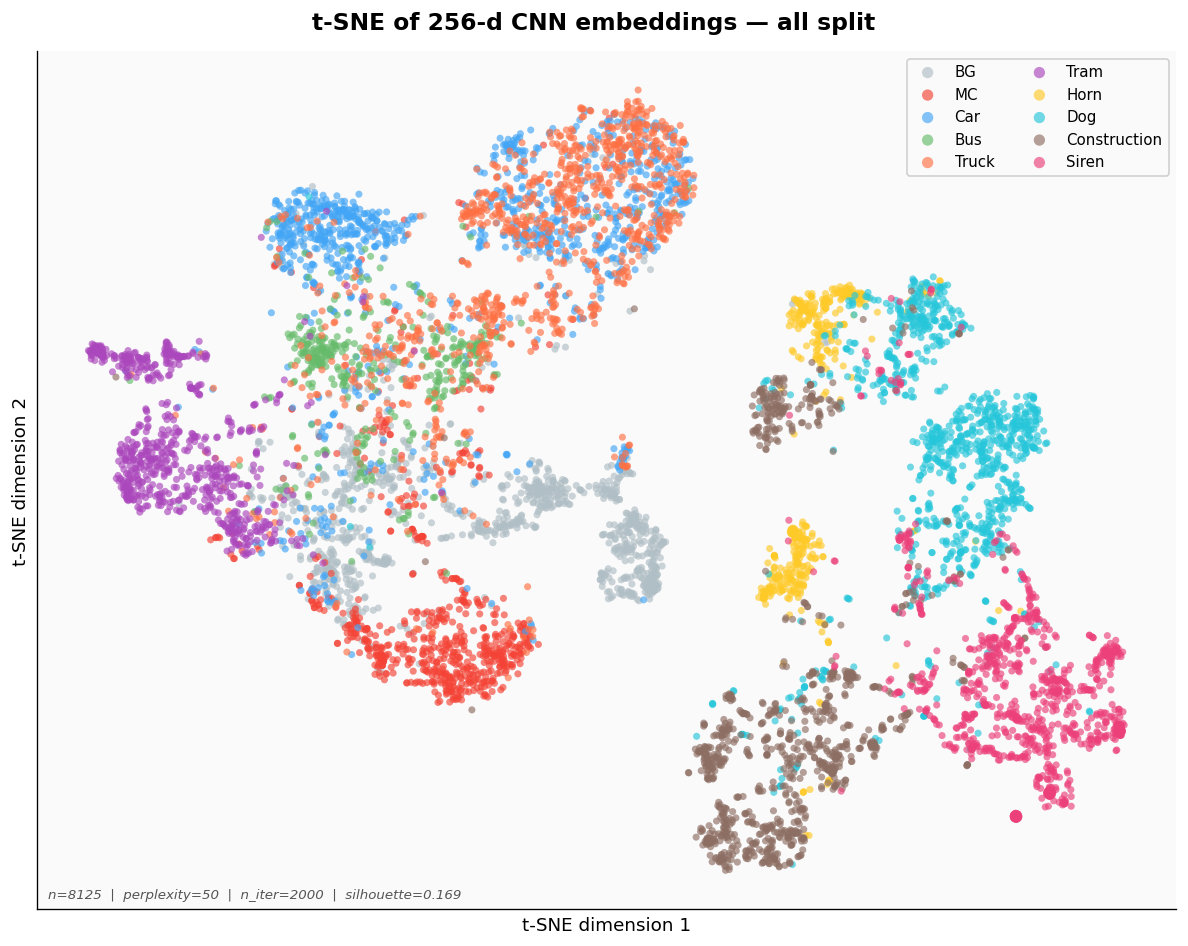

fig_tsne_1_scatter.png


In [10]:
fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle(f't-SNE of 256-d CNN embeddings — {SPLIT} split',
             fontsize=14, fontweight='bold')

for idx in range(N_CLASSES):
    cls  = IDX2CLASS[idx]
    mask = labels == idx
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               c=CLASS_COLORS[cls], s=18, alpha=0.65,
               edgecolors='none', label=cls, zorder=3)

ax.set_xlabel('t-SNE dimension 1', fontsize=11)
ax.set_ylabel('t-SNE dimension 2', fontsize=11)
ax.set_xticks([]); ax.set_yticks([])
ax.legend(loc='upper right', fontsize=9,
          markerscale=1.6, framealpha=0.9, ncol=2)

ax.text(0.01, 0.01,
        f'n={len(X_tsne)}  |  perplexity={PERPLEXITY}  |  '
        f'n_iter={N_ITER}  |  silhouette={sil:.3f}',
        transform=ax.transAxes, fontsize=8, color='#555',
        va='bottom', style='italic')

plt.tight_layout()
plt.savefig('fig_tsne_1_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("fig_tsne_1_scatter.png")

### Fig 2 – Per-class KDE density maps with labelled centroids

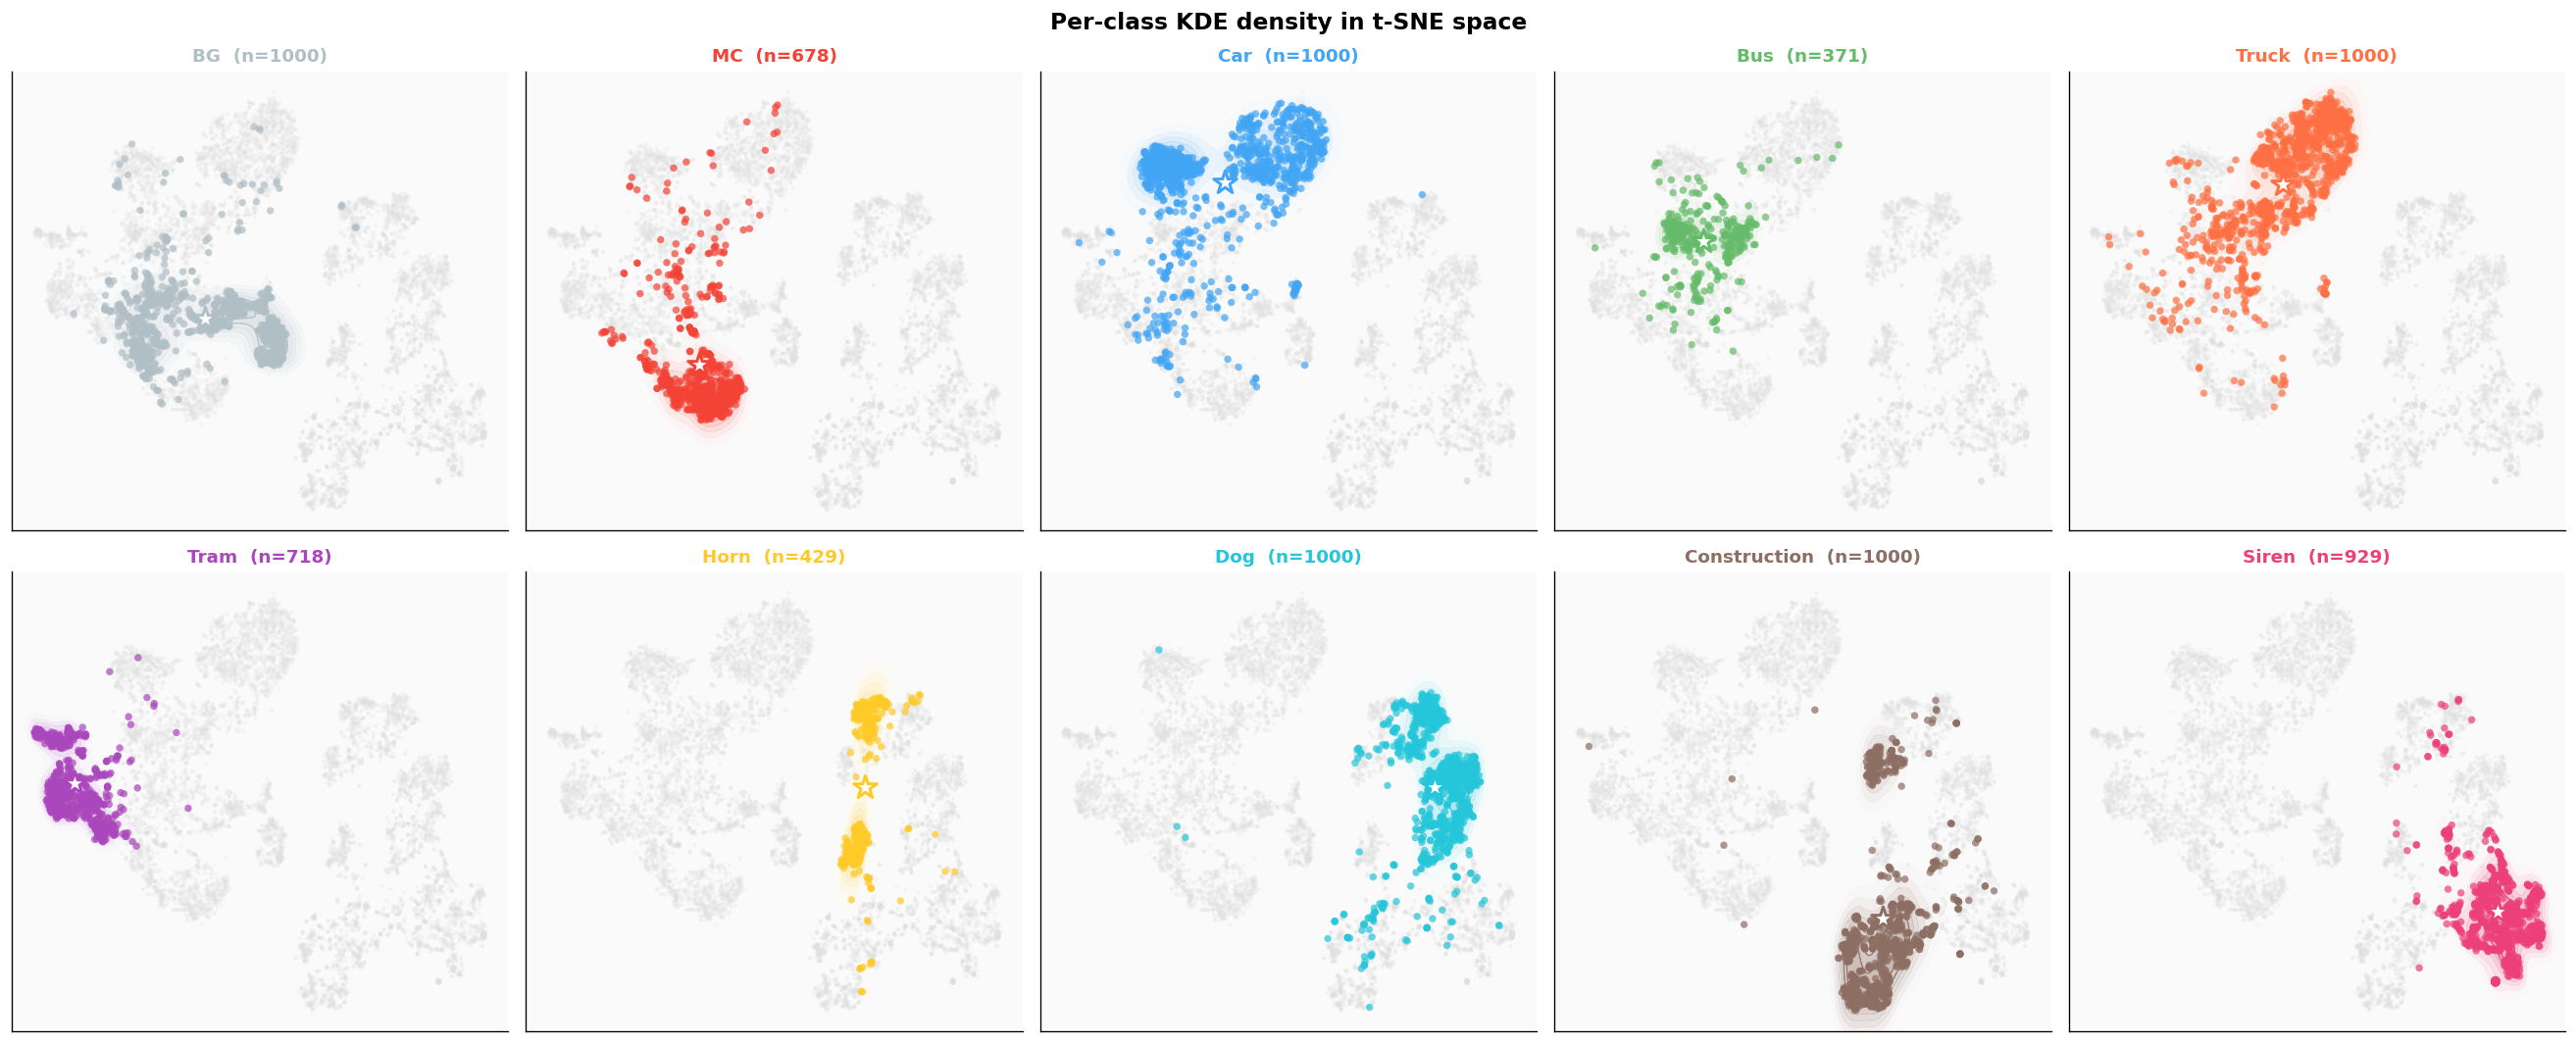

fig_tsne_2_kde.png


In [11]:
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes      = axes.flatten()
fig.suptitle('Per-class KDE density in t-SNE space',
             fontsize=14, fontweight='bold')

# Global axis limits with 5% margin
margin = 0.05
xmin, xmax = X_tsne[:, 0].min(), X_tsne[:, 0].max()
ymin, ymax = X_tsne[:, 1].min(), X_tsne[:, 1].max()
dx = (xmax - xmin) * margin; dy = (ymax - ymin) * margin
xlim = (xmin - dx, xmax + dx); ylim = (ymin - dy, ymax + dy)

xx, yy = np.mgrid[xlim[0]:xlim[1]:200j, ylim[0]:ylim[1]:200j]
pos    = np.vstack([xx.ravel(), yy.ravel()])

for idx, ax in enumerate(axes):
    cls  = IDX2CLASS[idx]
    mask = labels == idx
    pts  = X_tsne[mask]

    # Background: all points in grey
    ax.scatter(X_tsne[:, 0], X_tsne[:, 1],
               c='#e0e0e0', s=6, alpha=0.25, edgecolors='none', zorder=1)

    # Class points
    ax.scatter(pts[:, 0], pts[:, 1],
               c=CLASS_COLORS[cls], s=20, alpha=0.70,
               edgecolors='none', zorder=3)

    # KDE contour (only if enough samples)
    if mask.sum() >= 10:
        try:
            kde    = gaussian_kde(pts.T, bw_method='scott')
            zz     = kde(pos).reshape(xx.shape)
            levels = np.linspace(zz.min(), zz.max(), 9)[1:]
            cmap   = LinearSegmentedColormap.from_list(
                'cls', ['#ffffff00', CLASS_COLORS[cls]], N=256)
            ax.contourf(xx, yy, zz, levels=levels, cmap=cmap,
                        alpha=0.45, zorder=2)
            ax.contour(xx, yy, zz, levels=levels[-3:],
                       colors=[CLASS_COLORS[cls]], linewidths=0.8,
                       alpha=0.80, zorder=4)
        except Exception:
            pass

    # Centroid marker
    cx, cy = pts[:, 0].mean(), pts[:, 1].mean()
    ax.scatter(cx, cy, marker='*', s=220,
               c='white', edgecolors=CLASS_COLORS[cls],
               linewidths=1.8, zorder=6)

    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'{cls}  (n={mask.sum()})',
                 fontsize=11, fontweight='bold',
                 color=CLASS_COLORS[cls])

plt.tight_layout()
plt.savefig('fig_tsne_2_kde.png', dpi=150, bbox_inches='tight')
plt.show()
print("fig_tsne_2_kde.png")

---

In [16]:
_elapsed = _time.perf_counter() - _NOTEBOOK_START
_h, _rem = divmod(int(_elapsed), 3600)
_m, _s   = divmod(_rem, 60)

print("=" * 60)
print("TOTAL NOTEBOOK RUNTIME")
print("=" * 60)
if _h:
    print(f"  {_h}h {_m:02d}min {_s:02d}s  ({_elapsed:.1f}s total)")
elif _m:
    print(f"  {_m}min {_s:02d}s  ({_elapsed:.1f}s total)")
else:
    print(f"  {_s}s  ({_elapsed:.2f}s total)")
print("=" * 60)

TOTAL NOTEBOOK RUNTIME
  8min 51s  (531.7s total)
